<a href="https://colab.research.google.com/github/jollyoli93/jackoliver_24862664_dissertation/blob/main/Crane_Detector_YOLOv8_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -r /content/jackoliver_24862664_dissertation

In [ ]:
!cd ~

#Load Test Data

In [ ]:
# from google.colab import userdata

In [ ]:
!git clone https://github.com/jollyoli93/jackoliver_24862664_dissertation.git

In [ ]:
!ls

In [ ]:
%cd jackoliver_24862664_dissertation

In [ ]:
!pip install roboflow
!pip install pyyaml

from roboflow import Roboflow
rf = Roboflow(api_key='MYzeeHsKmZnJ360DkKYF')
project = rf.workspace("masterproject-mvazq").project("test_only")
version = project.version(7)
dataset = version.download("yolov8")

In [ ]:
!pwd

#Starter Code

In [ ]:
test_folder = '/content/jackoliver_24862664_dissertation/TEST_ONLY-7'

In [ ]:
!python --version

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install ultralytics==8.3.190

In [ ]:
# !pip install --upgrade onnx onnxscript

In [ ]:
# !pip install wandb

In [ ]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
# import cv2
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def extract_coords(coords):
    coord_split = [
        [float(x) for x in line.strip().split()]
        for line in coords
        if line.strip()
    ]
    return coord_split


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from pathlib import Path

from math import sqrt

#Gets statistics from training data for MLP ROI Predictor
def get_pairs(coords, from_file=True):

  coord_split = []

  if from_file:
    coord_split = extract_coords(coords)
  else:
    coord_split = coords

  hooks = [d for d in coord_split if d[0] == 0]  # hook
  loads = [d for d in coord_split if d[0] == 1]  # load

  pairs = {'hook': [], 'load': []}
  used_hooks = set()

  for load in loads:
      xc_load, yc_load = load[1], load[2]
      h_load = load[-1]
      closest = None
      closest_idx = -1
      min_dist = float("inf")

      for i, hook in enumerate(hooks):
          if i in used_hooks:
              continue

          xc_hook, yc_hook = hook[1], hook[2]

          yt_load = yc_load - (h_load /2)
          yb_hook = yc_hook + hook[-1]/2 #Location at bottom of hook

          # Hook must be above load
          if yb_hook > yt_load:
              continue

          # Horizontal closeness
          dist = abs(xc_load - xc_hook)
          if dist < min_dist:
              min_dist = dist
              closest = hook
              closest_idx = i

      if closest is not None:
          xc, yc, w, h = closest[1:5]
          # aspect = w / h if h != 0 else 0.0
          # area = w*h
          yb = yc + (h / 2)
          #dist = sqrt((xc - xc_load)**2 + (yc - yc_load)**2). feading load dims to features might create shortcut/memorisations

          # # get relative offsets normalised
          dx = (xc_load - xc) /w
          dy = (yc_load - yb) /h

          pairs['hook'].append(
              [xc, yc, w, h] + [yb]
          )
          pairs['load'].append([dx, dy])

          used_hooks.add(closest_idx)

  return pairs

In [ ]:
!unzip labels.zip

In [ ]:
train_labels = "/content/jackoliver_24862664_dissertation/labels"

# 1. Collect all data for fitting
train_feats = []
train_targets = []

for label_file in Path(train_labels).glob("*.txt"):
    with open(label_file) as f:
        pairs = get_pairs(f.readlines())
        if pairs:
            train_feats.extend(pairs['hook'])
            train_targets.extend(pairs['load'])

# 2. Fit the scalers
feat_scaler = StandardScaler().fit(train_feats)
target_scaler = StandardScaler().fit(train_targets)

In [ ]:
from joblib import dump, load

# Export the scaler with its learned statistics
dump(feat_scaler, 'feat_scaler.pkl')
dump(target_scaler, 'target_scaler.pkl')

In [ ]:
# loaded_scaler = load('standard_scaler.pkl')
# X_new_scaled = loaded_scaler.transform()

In [ ]:
def crop_load(img, x, y, w, h):
  """
    Takes as input, top left corner, width and height.
  """
  crop_img = img.copy()
  cropped_img = crop_img[y:y+h,x:x+w]

  return cropped_img


In [ ]:
def box_gating(boxes, xdist=3):
  """
  Gating to prevent duplicated predictions.
  Function will pair hooks with obj detected loads or roi detected search spaces predicted from hooks.
    Boxes contain a list of [class_idx, xc, yc, w, h, conf, src, hook_id] in pixel space.
    class 0 = hook, class 1 = load
    src in {"hook","obj","roi"}
    hook_id is an int for hook/roi loads, None for obj loads
    Returns loads only
    xdist sets the search distance in x direction under the hook.
  """
  if not boxes:
    print("No gating as boxes are empty.")
    return []

  hooks = [d for d in boxes if d[6] == "hook"]
  obj_loads = [d for d in boxes if d[6] == "obj"]
  roi_loads  = [d for d in boxes if d[6] == "roi"]

  print(f"hooks: {hooks}, obj_loads: {obj_loads}, roi_loads: {roi_loads}")

  if not hooks and not roi_loads:
    print("Load prediciton only")
    return obj_loads

  used_obj = set()
  matched_obj = set()
  kept_loads = []

  # For each hook find its highest matching load
  for hook in hooks:
    hook_x, hook_y, hook_w = hook[1], hook[2], hook[3]
    hook_id = hook[7]
    hook_boundary = hook_w * xdist #Increase X distance where load might be
    print(hook_w, "Hook x")
    print(hook_boundary, "X distance")

    best_obj_idx = None
    best_obj_conf = float("-inf")

    # First match obj detected loads
    for i, load in enumerate(obj_loads):
      load_x, load_y = load[1], load[2]

      # Gating - if it doesnt match then assume its on another hook
      if load_y < hook_y:
        continue
      if load_x < (hook_x - hook_boundary) or load_x > (hook_x + hook_boundary):
        continue

      matched_obj.add(i)

      if i in used_obj:
        continue

      conf = load[5]
      if conf > best_obj_conf:
        best_obj_conf = conf
        best_obj_idx = i

    # Check is hook has been matched with a true obj detected load if not use roi
    if best_obj_idx is not None:
      kept_loads.append(obj_loads[best_obj_idx])
      used_obj.add(best_obj_idx)
    else:
      roi_candidate = [d for d in roi_loads if d[7] == hook_id]
      if roi_candidate:
        kept_loads.append(roi_candidate[0])

  #keep all first pass obj detected loads if no hook is matched
  for i, load in enumerate(obj_loads):
    if i not in matched_obj:
      kept_loads.append(load)

  return kept_loads

In [ ]:
def corner_to_center(xt, yt, w,h):
  xc = xt+(w/2)
  yc = yt+(h/2)
  return xc, yc, w, h

In [ ]:
def center_to_corners(xc, yc, w,h):
  xl = xc - (w/2)
  xr = xc + (w/2)
  yt = yc - (h/2)
  yb = yc + (h/2)
  return xl, xr, yt, yb, w, h

#One Cycle

## Load YOLO Model

In [ ]:
best_weights = "/content/jackoliver_24862664_dissertation/YOLOv8n.pt"
yolo_model = YOLO(best_weights)

In [ ]:
test_img = '/content/jackoliver_24862664_dissertation/test_img.jpg'

In [ ]:
!ls

## Run Image

In [ ]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread(test_img)

cv2_imshow(img)

In [ ]:
img.shape

## Load Regression Model

In [ ]:
import torch

class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat)
        )

    def forward(self, x):
        x = self.linear(x)
        return x

In [ ]:
PATH = "/content/jackoliver_24862664_dissertation/LoadRegressionAdam250.pth"
cropPredict = LinearRegression(5, 2, 250)
cropPredict.load_state_dict(torch.load(PATH, weights_only=True, map_location=torch.device('cpu')))
cropPredict.eval()

In [ ]:
import numpy as np
import torch

def predict_load_roi(img_size, hook_coords):
    """
    hook_coords: normalized YOLO (x_center, y_center, w, h) in [0,1]
    img_size: (img_height, img_width) or (H, W, C) - we use first two.
    """

    # image dims
    img_height = int(img_size[0])
    img_width  = int(img_size[1])

    hook_coords_np = np.asarray(hook_coords, dtype=np.float32).reshape(-1)

    x, y, w, h = hook_coords_np  # normalized
    yb_hook = y + (h / 2.0)

    # features for scaler: [x, y, w, h, yb_hook]
    hook_features = np.array([[x, y, w, h, yb_hook]], dtype=np.float32)
    xs_scaled = feat_scaler.transform(hook_features)  # numpy (1, 5)

    # ---- Get predictions ------
    xs_t = torch.from_numpy(xs_scaled).float() #.to(device)
    cropPredict.eval()
    with torch.no_grad():
        pred_scaled = cropPredict(xs_t).cpu().numpy()
    print(pred_scaled, "predicitons")

    # pred_inv is [dx, dy]
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(1, -1))

    print(pred_inv, "Preds inversed")

    dx, dy = float(pred_inv[0, 0]), float(pred_inv[0, 1])

    # ---- Get  offsets relative to hook size (still normalized to hook dimensions [0-1]) ----
    x_offset = dx * w
    y_offset = dy * h

    # Get absolute load center position
    x_pred = x + x_offset
    y_pred = yb_hook + y_offset

    #Scale predictions to actual size
    xc = int(round(x_pred * img_width ))
    yc = int(round(y_pred * img_height))

    #---- Calculate the crop width and height from measurments ----
    hook_h_s = (h * img_height)/100
    hook_w_s = (w * img_width)/100

    crop_h = min(int(y_offset * img_height * (1 + hook_h_s)), int(y_offset * img_height * 1.6))   # Use distance from load to hook_b as height of crop and scale by hook height. Crop h cant be greater than 2x offset
    crop_w = int(crop_h)      # Assume loads are wider than they are tall - scale by additional hook width
    # crop_w = int(crop_h * (1 + hook_w_s))      # Assume loads are wider than they are tall - scale by additional hook width
    print(crop_h, crop_w, "xc, yc")

    xt = int(xc - (crop_w // 2))
    yt = int(yc - (crop_h // 2))

    # Clamp to image bounds
    xt = max(0, min(xt, img_width - crop_w))
    yt = max(0, min(yt, img_height - crop_h))

    print(xt, yt, crop_w, crop_h)
    return xt, yt, crop_w, crop_h


## Load Classifier Model

In [ ]:
!pwd

In [ ]:
#Model stored in HuggingFace due to size
!pip install -q huggingface_hub
!hf download jollyoli93/crane_classifier crane_classifier.pth --local-dir ./model

In [ ]:
classifier_model = '/content/jackoliver_24862664_dissertation/model/crane_classifier.pth'

In [ ]:
import torch
import albumentations as A
import numpy as np

checkpoint = torch.load(classifier_model, map_location='cpu', weights_only=False)

class_model = checkpoint['model']
class_model.eval()

if torch.cuda.is_available():
    class_model = class_model.cuda()

cls_names = checkpoint['cls_names']
cls_index = checkpoint['cls_index']

print("Model loaded successfully!")

In [ ]:
cls_names

In [ ]:
val_transforms = A.Compose([
    A.Resize(height=240, width=240, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0), #ImageNet statictics
])

In [ ]:
def predict_one_image(model, image_array, transforms=val_transforms):
    """
    Predict class for a single image from test set
    """
    model.eval()

    # Apply transforms
    transformed = transforms(image=image_array)['image']
    x = np.transpose(transformed, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

    # Move to GPU if available
    if torch.cuda.is_available():
        x = x.cuda()

    with torch.no_grad():
        output = model(x)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    pred_class = cls_names[pred_idx]

    return pred_class, confidence


In [ ]:
# # Test prediction
# predicted_class, confidence = predict_one_image(class_model, img)

# print(f"Predicted Class: {predicted_class}")
# print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

## One Cycle - Crane Load Predictor

In [ ]:
def second_stage_detector(crop, img_size):
  print("Predicting Second Crop")
  results = yolo_model.predict(crop, imgsz=img_size, stream=False)

  for result in results:
    if not result.boxes:
      continue

    for box in result.boxes.cpu():
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        if class_id == 1: #Load Class
        #  LOCAL coordinates (relative to the ROI)
          lx1, ly1, lx2, ly2 = box.xyxy[0].cpu().numpy().astype(int)
          print(lx1, ly1, lx2, ly2)

          w, h = lx2 - lx1, ly2 - ly1
          print("w,h: ", w, " " , h)
          # actual cropped image of the load
          load_only_crop = crop[ly1:ly2, lx1:lx2]
          return load_only_crop, lx1, ly1, lx2, ly2, conf
  return None, 0,0,0,0, 0

In [ ]:
def predict_from_hook(image, box_size, dims,class_model, second_detect=True):
    pts = predict_load_roi(box_size, dims)
    xt, yt, crop_w, crop_h = pts
    print(xt, yt)

    # extract the ROI from the main image
    ROI = image[yt:yt+crop_h, xt:xt+crop_w]
    if ROI.size == 0: return

    cv2.rectangle(img, (xt, yt), (xt + crop_w, yt + crop_h), (0, 255, 0), 2)
    cv2.putText(img, f"ROI", (xt, yt - 10),
      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

    # Find the load inside that ROI
    load_crop, lx1, ly1, lx2, ly2, yolo_conf = second_stage_detector(ROI, max(crop_w, crop_h))

    if load_crop is not None and second_detect:
        # GLOBAL COORDINATES: ROI start + Local YOLO start
        gx1, gy1 = xt + lx1, yt + ly1
        gx2, gy2 = xt + lx2, yt + ly2
        w = gx2 - gx1
        h = gy1 - gy2

        # Draw the final accurate box
        predicted_class, confidence = predict_one_image(class_model, load_crop)
        cv2.rectangle(img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 3)
        cv2.putText(img, f"Predicted 2 stage Crop: {predicted_class}, Conf: {confidence:.2f}", (gx1, gy1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        return gx1, gy1, h ,w, confidence
    else:
        print("MLP proposed a region, but YOLO stage 2 found no load there.")
        print("Predicting from ROI")
        print()

        predicted_class, confidence = predict_one_image(class_model, ROI)
        print(f"Predicted ROI Class: {predicted_class}")
        print(f"Confidence of ROI: {confidence:.4f} ({confidence*100:.2f}%)")

        cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
        cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
        # returns corner point and crop w, h
        return xt, yt, crop_w, crop_h, confidence

In [ ]:
# Run prediction on the image
img = cv2.imread(test_img) #1 hook, 1 load

In [ ]:
results = yolo_model.predict(img)

In [ ]:
results

In [ ]:
# Iterate over the results

for result in results:
    boxes = result.boxes.cpu()  # Get boxes on CPU in numpy format
    print(boxes)
    box_preds = []

    for idx, box in enumerate(boxes):  # Iterate over boxes
        r = box.xyxy[0].cpu().numpy().astype(int) # Get corner points as int (Actual Co-ords)

        class_id = int(box.cls[0])  # Get class ID
        class_name = yolo_model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        # First check if a load was detected
        if class_id == 1: #Load Class
          print("\nLoad detected")
          xt, yt, xb, yb = r.tolist()
          w, h = box.xywh[0].cpu().numpy().astype(int)[2:4]

          w, h = int(w), int(h)

          crop = crop_load(img, xt,yt,w,h)
          cv2_imshow(crop)

          #classify
          predicted_class, confidence = predict_one_image(class_model, crop)
          print(f"Predicted Original Class: {predicted_class}")
          print(f"Confidence of Original: {confidence:.4f} ({confidence*100:.2f}%)")

          cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
          cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

          # Append to box_preds for gating
          center = corner_to_center(xt, yt, w, h)
          if isinstance(center, np.ndarray):
              center = center.tolist()
          center = [float(center[0]), float(center[1]), float(center[2]), float(center[3])]

          # use OD conf not class for gating if load is detected
          box_preds.append([1, *center, conf, "obj", None])

        # If no load was detected then detect from hook
        else:
          print("No load detected - predicting from hook")
          hook_dims_n = box.xywhn[0]
          hook_dims = box.xywh[0].cpu().tolist()
          print("Hook found - Crop ROI")
          xt,yt, w,h, confidence = predict_from_hook(img, box.orig_shape, hook_dims_n, class_model, False)
          print("hook load",xt,yt, w,h, " Center:", corner_to_center(xt, yt, w, h))

          # Append to box_preds for gating
          center = corner_to_center(xt, yt, w, h)

          if isinstance(center, np.ndarray):
              center = center.tolist()
          center = [float(center[0]), float(center[1]), float(center[2]), float(center[3])]
          box_preds.append([0, *hook_dims, None, "hook", idx])
          box_preds.append([1, *center, confidence, "roi", idx])

    print(box_preds)
    gated_boxes = box_gating(box_preds)

In [ ]:
cv2_imshow(img)

# Know Your Load Exactly

## ROI Predict Class


In [ ]:
class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden):
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.linear(x)

class Roi_Predict:
  def __init__(self, model_path):
    self.model = LinearRegression(5, 2, 250)
    state = torch.load(model_path,
                        map_location="cpu",
                        weights_only=True)
    self.model.load_state_dict(state)
    self.model.eval()

  def predict_load_roi(self, img_size, hook_coords):
    """
    hook_coords: normalized YOLO (x_center, y_center, w, h) in [0,1]
    img_size: (img_height, img_width) or (H, W, C) - we use first two.
    returns: x top, y top, roi width, roi height
    """

        # image dims
    img_height = int(img_size[0])
    img_width  = int(img_size[1])

    hook_coords_np = np.asarray(hook_coords, dtype=np.float32).reshape(-1)

    x, y, w, h = hook_coords_np  # normalized
    yb_hook = y + (h / 2.0)

    # features for scaler: [x, y, w, h, yb_hook]
    hook_features = np.array([[x, y, w, h, yb_hook]], dtype=np.float32)
    xs_scaled = feat_scaler.transform(hook_features)  # numpy (1, 5)

    # ---- Get predictions ------
    xs_t = torch.from_numpy(xs_scaled).float() #.to(device)
    cropPredict.eval()
    with torch.no_grad():
        pred_scaled = cropPredict(xs_t).cpu().numpy()

    # pred_inv is [dx, dy]
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(1, -1))
    dx, dy = float(pred_inv[0, 0]), float(pred_inv[0, 1])

    # ---- Get  offsets relative to hook size (still normalized to hook dimensions [0-1]) ----
    x_offset = dx * w
    y_offset = dy * h

    # Get absolute load center position
    x_pred = x + x_offset
    y_pred = yb_hook + y_offset

    #Scale predictions to actual size
    xc = int(round(x_pred * img_width ))
    yc = int(round(y_pred * img_height))

    #---- Calculate the crop width and height from measurments ----
    hook_h_s = (h * img_height)/100
    hook_w_s = (w * img_width)/100

    crop_h = int(y_offset * img_height * (1 + hook_h_s))    # Use distance from load to hook_b as height of crop and scale by hook height. Crop h cant be greater than 2x offset
    crop_w = int(crop_h * (1 + hook_w_s))      # Assume loads are wider than they are tall - scale by additional hook width

    xt = int(xc - (crop_w // 2))
    yt = int(yc - (crop_h // 2))

    # Clamp to image bounds
    xt = max(0, min(xt, img_width - crop_w))
    yt = max(0, min(yt, img_height - crop_h))

    return xt, yt, crop_w, crop_h


## Load Classifier Class

In [ ]:
import torch
import albumentations as A
import numpy as np

class Load_Classify:
    def __init__(self, path_to_model):
        self.path = path_to_model
        checkpoint = torch.load(
            self.path,
            map_location='cpu',
            weights_only=False
        )

        self.class_model = checkpoint["model"]
        self.class_model.eval()

        if torch.cuda.is_available():
            self.class_model.cuda()

        self.cls_names = checkpoint["cls_names"]
        self.cls_index = checkpoint["cls_index"]
        self.val_transforms = A.Compose([
            A.Resize(height=240, width=240),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225),
                        max_pixel_value=255.0),
        ])

    def predict_one_image(self, image_array):
        model = self.class_model
        transforms = self.val_transforms

        # model.eval()
        transformed = transforms(image=image_array)['image']
        x = np.transpose(transformed, (2, 0, 1))
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

        if torch.cuda.is_available():
            x = x.cuda()

        with torch.no_grad():
            output = model(x)
            probs = torch.softmax(output, dim=1)
            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()

        pred_class = self.cls_names[pred_idx]
        return pred_class, confidence

## KYLE Class

In [ ]:
from pydantic import BaseModel

class Box_Result(BaseModel):
    x_c: int
    y_c: int
    width: int
    height: int
    conf: float
    class_type: str

class Image_Result(BaseModel):
    image_name: str
    image_path: str
    image_size: tuple
    image_results: list[Box_Result]

In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
from pathlib import Path

def cv_show(name, image):
    cv2.imshow(name, image)
    cv2.waitKey(5000)
    cv2.destroyAllWindows()

class KYLE:
    def __init__(self, objd_model, ob_weights, roi_model, classify_model, second_detect=True):
        self.objd_model = objd_model(ob_weights)
        self.objd_model_ss = objd_model(ob_weights)
        self.roi_predict = roi_model
        self.classify_model = classify_model
        self.predictions = []
        self.second_detect=second_detect

    def _crop_load(self, img, x, y, w, h):
        return img[y:y+h, x:x+w]


    def _second_stage_detector(self, crop, roi_size):
      """
        From ROI crop predict new object using YOLO
        If object found returns cropped image, local x1 x2, local y1 y2, confidence
        Else - None, 0,0,0,0,0

      """
      print("Predicting Second Crop")
      ss_results = self.objd_model_ss.predict(crop, imgsz=roi_size, stream=False)

      for result in ss_results:
        if not result.boxes:
          continue

        for box in result.boxes.cpu():
            class_id = int(box.cls[0])
            class_name = self.objd_model_ss.names[class_id]  # Get class name using the class ID
            conf = float(box.conf[0])
            label = f"{class_name}: {conf:.2f}"

            if class_id == 1: #Load Class
            #  LOCAL coordinates (relative to the ROI) top left, bottom right
              lx1, ly1, lx2, ly2 = box.xyxy[0].cpu().numpy().astype(int)

              # actual cropped image of the load
              load_only_crop = crop[ly1:ly2, lx1:lx2]
              return load_only_crop, lx1, ly1, lx2, ly2, conf
      return None, 0,0,0,0, 0

    def _predict_from_hook(self, image, box_size, hook_dims, second_detect=True):
      """ Input original image, predict the ROI from first pass
          Pass through second stage object detector.
          Classify results
          returns x left, y top, w, h
       """
      print("predict from hook box size and dims",box_size, hook_dims)
      roi = self.roi_predict.predict_load_roi(box_size, hook_dims)
      xl, yt, crop_w, crop_h = roi

      # extract the ROI from the main image
      ROI = image[yt:yt+crop_h, xl:xl+crop_w]
      if ROI.size == 0: return

      # Find the load inside that ROI
      load_crop, lx1, ly1, lx2, ly2, yolo_conf = self._second_stage_detector(ROI, max(crop_w, crop_h))

      if load_crop is not None and second_detect:
        print("Second ROI detected \n")
        # GLOBAL COORDINATES: ROI start + Local YOLO start
        gx1, gy1 = xl + lx1, yt + ly1
        gx2, gy2 = xl + lx2, yt + ly2

        w, h = gx2 - gx1, gy2 - gy1

        # Draw the final accurate box
        # predicted_class, confidence = self.classify_model.predict_one_image(load_crop)
        # xl, yt, w, h
        print("Second predict", gx1,gy1,w,h)
        return gx1,gy1,w,h
        # return gx1, gy1
      elif not second_detect:
        print("MLP proposed a region, but YOLO stage 2 found no load there. \n")
        # xl, yt, w, h
        return roi
      else:
        print("Returning ROI")
        return roi

    # Object detection
    def _predict_one_img(self, result, _img, idx, predict_from_hook=True):
      load_results = None

      if not result.boxes:
        print("No results")
        image_name = str(getattr(result, "path", f"frame_{idx}")).rsplit("/", 1)[-1]

        return Image_Result(image_name=image_name, image_path=getattr(result, "path", None),
                    image_results=[], image_size=result.orig_shape)

      box_preds = []

      #Parse all hook and load predictions
      for idx, box in enumerate(result.boxes.cpu()):
        class_id = int(box.cls[0])  # Get class ID
        class_name = self.objd_model.names[class_id]  # Get class name using the class ID
        obj_conf = float(box.conf[0])
        label = f"{class_name}: {obj_conf:.2f}"

        # -----------------------------------
        # LOAD (class 1) - If YOLO Predicts load then append the load dims for predictions
        # -----------------------------------
        if class_id == 1:
            xc, yc, w, h = box.xywh[0].cpu().numpy().tolist()
            xc, yc, w, h = int(xc), int(yc), int(w), int(h)
            xl = xc - (w//2)
            yt = yc - (h//2)

            xl = int(xl)
            yt = int(yt)
            w  = int(w)
            h  = int(h)

            # use OD conf for gating. Return prediction type "obj"
            box_preds.append([1, xc, yc, w, h, obj_conf, "obj", None])

        # -----------------------------------
        # HOOK (class 0) - if hook is present then find load using ROI prediction
        # -----------------------------------
        elif predict_from_hook:
          hook_dims_n = box.xywhn[0]
          hook_dims = box.xywh[0].cpu().tolist()

          print("Hook found - Crop ROI")
          roi_dims = self._predict_from_hook(_img, box.orig_shape, hook_dims_n)

          if roi_dims is None:
            print("ROI is empty")
            continue

          roi_crop = self._crop_load(_img, *roi_dims)

          center = corner_to_center(*roi_dims)

          if isinstance(center, np.ndarray):
              center = center.tolist()

          center = [int(center[0]), int(center[1]), int(center[2]), int(center[3])]

          #Return hook and predicted ROI to overall image predictions
          box_preds.append([0, *hook_dims, None, "hook", idx])
          box_preds.append([1, *center, None, "roi", idx])

      #Image may have multiple hook and load predictions so overlapping predicitons are gated.
      gated_boxes = box_gating(box_preds)

      image_results = []

      for boxes in gated_boxes:
        xc, yc, w, h = boxes[1:5]
        xl,_, yt,_, w, h = center_to_corners(xc, yc, w, h)

        # clamp to ensure boundary limits
        xl = int(max(0, min(xl, _img.shape[1] - 1)))
        yt = int(max(0, min(yt, _img.shape[0] - 1)))
        w  = int(max(1, min(w, _img.shape[1] - xl)))
        h  = int(max(1, min(h, _img.shape[0] - yt)))

        crop = self._crop_load(_img, xl, yt, w, h)
        pred_class, confidence = self.classify_model.predict_one_image(crop)

        box_result = Box_Result(
              class_type=pred_class,
              x_c=xc,
              y_c=yc,
              width=w,
              height=h,
              conf=confidence,
              )
        image_results.append(box_result)

      image_name = result.path.rsplit("/", 1)[-1]
      load_results = Image_Result(image_name=image_name, image_path = result.path,image_results = image_results, image_size=result.orig_shape)
      return load_results

    #Run inference
    def detect(self, input):
        results = self.objd_model.predict(input, stream=False)
        if results is None:
          print("No predictions")
          return

        crop_results = None

        if isinstance(self.objd_model, YOLO):
            outputs = []
            for r in results:
              print("\n**** Plotting Image Results ****")
              img = r.orig_img
              out = self._predict_one_img(r, img, idx=1)
              outputs.append(out)
              self.predictions.append(out)
              print("**** Returning results ****")
            return outputs

    # #Run inference on bulk images - upload array of images.
    def detect_stream(self, stream):
        results = self.objd_model.predict(stream, stream=True)

        for i, r in enumerate(results):
          print(f"\n**** Plotting Image Results {i} ****")
          img = r.orig_img
          out = self._predict_one_img(r, img, idx=i)
          self.predictions.append(out)
          print("**** Returning results ****")
          yield out, r

    #Run inference on YOLO detector only
    def detect_yolo_only(self, input):
        results = self.objd_model.predict(input, stream=False)
        if results is None:
          print("No predictions")
          return

        crop_results = None

        if isinstance(self.objd_model, YOLO):
            outputs = []
            for r in results:
                print("\n**** Plotting Image Results ****")
                img = r.orig_img
                out = self._predict_one_img(r, img, idx=1, predict_from_hook=False)
                outputs.append(out)
                self.predictions.append(out)
            print("**** Returning results ****")
            return outputs

    # #Run inference on bulk images - upload array of images.
    def detect_stream_yolo(self, stream):
        results = self.objd_model.predict(stream, stream=True)

        for i, r in enumerate(results):
          print(f"**** \nPlotting Image Results {i} ****")
          img = r.orig_img
          out = self._predict_one_img(r, img, idx=i, predict_from_hook=False)
          self.predictions.append(out)
          print("**** Returning results ****")
          yield out, r

In [ ]:
best_weights = "/content/jackoliver_24862664_dissertation/YOLOv8n.pt"
yolo_model = YOLO(best_weights)

ROI_PATH = "/content/jackoliver_24862664_dissertation/LoadRegressionAdam250.pth"
roi_predict = Roi_Predict(ROI_PATH)

CLS_PATH = classifier_model
class_model = Load_Classify(CLS_PATH)

In [ ]:
class_index = class_model.cls_names; class_index

# Run KYLE Model

In [ ]:
kyle = KYLE(YOLO, best_weights, roi_predict, class_model, second_detect=False)

In [ ]:
img = cv2.imread(test_img) #1 hook, 1 load
# img = '/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg' #1 hook, 1 load

In [ ]:
cv2_imshow(img)

In [ ]:
# kyle.detect_yolo_only(img)
kyle.detect(img)

In [ ]:
preds = kyle.predictions

In [ ]:
preds[0].image_results

### Plot Boxes

In [ ]:
# res1, res2 = preds[0].image_results
# dims1 = res1.x_c, res1.y_c, res1.width, res1.height
# dims2 = res2.x_c, res2.y_c, res2.width, res2.height

# corners1 = center_to_corners(*dims1)
# corners2 = center_to_corners(*dims2)

In [ ]:
preds[0].image_results[0]

In [ ]:
res1 = preds[0].image_results[0]
dims1 = res1.x_c, res1.y_c, res1.width, res1.height

corners1 = center_to_corners(*dims1)

In [ ]:
def show_image_bb(im, dims):
  pt1 = (int(dims[0]), int(dims[2])) #top left corner
  pt2 = (int(dims[1]), int(dims[3])) #bottom right corner

  cv2.rectangle(im, pt1, pt2, (0, 255, 0), 2)
  cv2_imshow(im)

In [ ]:
show_image_bb(img, corners1)

## Run YOLO Only

In [ ]:
img = cv2.imread(test_img)
yolo_result = kyle.detect_yolo_only(img)

In [ ]:
yolo_result

In [ ]:
imgs = yolo_result[0].image_results[0]

In [ ]:
imgs

In [ ]:
dims = imgs.x_c, imgs.y_c, imgs.width, imgs.height

corners = center_to_corners(*dims)

In [ ]:
show_image_bb(img, corners)

#Define Tests

In [ ]:
test_path = Path(test_folder+"/test")

test_image_path = test_path / "images"
test_labels_path = test_path / "labels"

test_images = [img for img in test_image_path.glob("*.jpg")]
test_labels = [img for img in test_labels_path.glob("*.txt")]

In [ ]:
test_labels

In [ ]:
type(test_images[0]), test_labels[0]

## Parse/Load Testset into Dataframe

In [ ]:
import yaml

def parse_yaml(PATH):
  cls_names = []
  test_path = None
  train_path = None
  valid_path = None

  with open(PATH) as stream:
      try:
          yamlLoad = yaml.safe_load(stream)
          cls_names = yamlLoad['names']
          test_path = yamlLoad['test']
          train_path = yamlLoad['train']
          valid_path = yamlLoad['val']
      except yaml.YAMLError as exc:
          print(exc)
  return cls_names, test_path, train_path, valid_path


In [ ]:
test_classes_yaml = parse_yaml(test_folder+"/data.yaml");
test_classes = test_classes_yaml[0]

In [ ]:
test_classes

In [ ]:
# testset_rows =[]

# for label in test_labels:
#   img_name = label.stem

#   with open(label, "r") as f:
#     file = f.readlines()
#     coords = extract_coords(file)
#     print(coords)
#     for i, c in enumerate(coords):
#       cls_idx = int(c[0])

#       print(cls_idx, test_classes)
#       cls_name = test_classes[cls_idx]
#       row = {
#               "image": img_name,
#               "gt_box_index": i,
#               "gt_class_idx": cls_idx,
#               "gt_class": cls_name,
#               "xc": c[1],
#               "yc": c[2],
#               "w": c[3],
#               "h": c[4]
#           }

#       testset_rows.append(row)


# testset_df = pd.DataFrame.from_dict(testset_rows)

# #Save testset output to CSV
# filepath = Path("/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/TEST_ONLY-7.csv")
# filepath.parent.mkdir(parents=True, exist_ok=True)
# testset_df.to_csv(filepath)

In [ ]:
testset_df = pd.read_csv("/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/TEST_ONLY-7.csv")

## Define Test Method

In [ ]:
kyle = KYLE(YOLO, best_weights, roi_predict, class_model);

In [ ]:
def IOU(gt, pred):
  x_min = max(gt[0], pred[0])
  x_max = min(gt[1], pred[1])
  y_min = max(gt[2], pred[2])
  y_max = min(gt[3], pred[3])

  area_gt = (gt[4] * gt[5])
  area_pred = (pred[4] * pred[5])

  iw = max(0.0, x_max - x_min)
  ih = max(0.0, y_max - y_min)
  intersection = iw * ih

  union = area_gt + area_pred - intersection

  iou = intersection / union

  # print(x_min, x_max, y_min, y_max, area_gt, area_pred)
  # print("intersection: ", intersection)
  # print("union: ", union)
  # print("iou: ", iou)
  return iou

In [ ]:
def get_test_pairs(gt_labels, predict_labels, image_size, min_iou=0.0):
  """
  Takes ground_truth normalised labels [list] and actual box predictions as a list[box_preds]
  Check if gt box fits in prediction box using IOU
  if multiple return best IOU -
  return [gt_index, predict_index, best_iou]
  """
  pairs = []
  pred_dims_list = []

  #get prediction box
  for pred in predict_labels:
      pred_dims = center_to_corners(
          pred.x_c,
          pred.y_c,
          pred.width,
          pred.height
      )

      pred_dims_list.append(pred_dims)

  for gt_idx, label in enumerate(gt_labels):

      gt_xc = label[1] * image_size[1]
      gt_yc = label[2] * image_size[0]
      gt_w  = label[3] * image_size[1]
      gt_h  = label[4] * image_size[0]

      gt_dims = center_to_corners(
          gt_xc,
          gt_yc,
          gt_w,
          gt_h
      )

      best_pred_idx = None
      best_iou = min_iou

      for pred_idx, pred_dims in enumerate(pred_dims_list):

          iou = IOU(gt_dims, pred_dims)

          if iou > best_iou:
              best_iou = iou
              best_pred_idx = pred_idx

      if best_pred_idx is not None:
          pairs.append(
              [gt_idx, best_pred_idx, best_iou]
          )

  return pairs

In [ ]:
cls_to_index = {i:cls for cls, i in class_index.items()}

In [ ]:
cls_to_index

In [ ]:
import gc

def test_preds(PATH, full_test=False, method="YOLO"):
  """
  Test method that returns pandas dataframe of the results.
  Set full_test to True to test all test images.
  Specify method type - YOLO, KYLE
  """

  yamlLoad = parse_yaml(PATH + "/data.yaml")
  cls_names, _, _, _ = yamlLoad
  print(f"Ground Truth: {cls_names}")

  cls_index = {i:cls for cls, i in class_index.items()}
  print(f"Classifier {cls_index}")

  test_path = Path(PATH+"/test")
  test_image_path = (test_path / "images")
  test_labels_path = (test_path / "labels")
  number_gt_loads = 0

  if full_test:
    test_images = [img for img in test_image_path.glob("*.jpg")]

  else:
    test_images = [Path("/content/jackoliver_24862664_dissertation/TEST_ONLY-7/test/images/2502181630004409_jpg.rf.99cf20a40cbd1d3107e30a0e916af346.jpg")] #test one imag

  print(f"****** Predicting {len(test_images)} images ********")

  # Set architecture test type
  predict = None

  match method:
    case "YOLO":
      print("YOLO Only Load Prediction")
      predict = kyle.detect_stream_yolo(test_images)
    case "KYLE":
      print("KYLE Achitecture Load Prediction")
      predict = kyle.detect_stream(test_images)
    case _:
      return "Method value incorrect"

  print(f"****** Prediction complete ********")

  result_rows = []
  results = pd.DataFrame(
    columns =
              ["image",
                "image_size",
                "gt_box_index",
                "gt_class_idx",
                "gt_class",
                "pred_box_index",
                "pred_class_idx",
                "pred_class",
                "conf",
                "iou"
                "xc",
                "yc",
                "w",
                "h"]
            )
  pairs = []

  print("***** Run results check *****")

  for i, out in enumerate(predict):
    print("Prediction recieved")
    img, yolo_res = out
    print(f"Prediction i={i}, img={img}")
    image_name = img.image_name.rsplit(".", 1)[0]
    image_label_path = test_labels_path / (image_name + ".txt")
    image_size = img.image_size
    box_results = img.image_results

    gt_label_dims = None

    with open(image_label_path, "r") as f:
      lines = f.readlines()
      gt_label_dims = extract_coords(lines)
      number_gt_loads += len(gt_label_dims)

    # If image has no loads label as background
    if not gt_label_dims:
      print("NO GT LABEL - BACKGROUND IMAGE")
      result_rows.append({
                      "image": image_name,
                      "image_size": image_size,
                      "gt_box_index": -1,
                      "gt_class_idx": -1,
                      "gt_class": "background",
                      "pred_box_index": -1,
                      "pred_class_idx": -1,
                      "pred_class": None,
                      "conf": None,
                      "iou":None,
                      "xc": None,
                      "yc": None,
                      "w": None,
                      "h": None
                  })
      continue

    # Match all gt_labels to all box_results using intersection over union for overlapping boxes
    pairs = get_test_pairs(gt_label_dims, box_results, image_size)

    if not pairs:
      print("No pairs - append empty result")
      result_rows.append({
                "image": image_name,
                "image_size": image_size,
                "gt_box_index": -1,
                "gt_class_idx": -1,
                "gt_class": None,
                "pred_box_index": -1,
                "pred_class_idx": -1,
                "pred_class": None,
                "conf": None,
                "iou":None,
                "xc": None,
                "yc": None,
                "w": None,
                "h": None
            })
      continue

    for gt_idx, pred_idx, iou in pairs:
      print("Pair matched - append result")
      gt_cls_idx = int(gt_label_dims[gt_idx][0])
      gt_cls = cls_names[gt_cls_idx]

      pred = box_results[pred_idx]

      pred_cls = pred.class_type
      pred_cls_idx = cls_index.get(pred_cls.lower())

      result_rows.append({
                "image": image_name,
                "image_size": image_size,
                "gt_box_index": gt_idx,
                "gt_class_idx": gt_cls_idx,
                "gt_class": gt_cls,
                "pred_box_index": pred_idx,
                "pred_class_idx": pred_cls_idx,
                "pred_class": pred_cls,
                "conf": pred.conf,
                "iou": iou,
                "xc": pred.x_c,
                "yc": pred.y_c,
                "w": pred.width,
                "h": pred.height
            })
    gc.collect()

  print(f"Number of GT Loads: {number_gt_loads}")
  results = pd.DataFrame(result_rows)
  return results, yolo_res
      # print(image_name, lines, "\n")
    # test_labels = [img for img in test_labels_path.glob(image_name+".txt")]

# Tests

## Test - Yolo Only (Base Case)

Set full_test=true to run on full test set

In [ ]:
res, _ = result_yolo_one = test_preds(test_folder, full_test=False)

In [ ]:
res

In [ ]:
res['true'] = (res['gt_class'] == res['pred_class']) & (res['gt_class'] != None)

In [ ]:
res.true.value_counts()

In [ ]:
res.pred_class.value_counts()

In [ ]:
res.gt_class.value_counts()

In [ ]:
# res.image.value_counts()


In [ ]:
count_all_preds = res[res['pred_class_idx'] > -1]; count_all_preds.shape[0]

In [ ]:
# #Save output to CSV
# filepath = Path("/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/yolo_res_10.09.csv")
# filepath.parent.mkdir(parents=True, exist_ok=True)
# res.to_csv(filepath)

YOLO Only has detected: \
Total of 69 images - 87 gt load

*   1 True Positives - 1 False pos is paired on manual inspection
*   19 False Positives
*   3 False Negatives (background predictions)



## Test - Enhanced Architecture

Set full_test=true to run on full test set

In [ ]:
kyle = KYLE(YOLO, best_weights, roi_predict, class_model, second_detect=False)

In [ ]:
kyle_res, _ = test_preds(test_folder, full_test=False, method="KYLE")

In [ ]:
kyle_res

In [ ]:
kyle_res['true'] = (kyle_res['gt_class'] == kyle_res['pred_class']) & (kyle_res['gt_class'] != None)

In [ ]:
kyle_res

In [ ]:
kyle_res.true.value_counts()

In [ ]:
kyle_res.pred_class.value_counts()

In [ ]:
count_all_preds = kyle_res[kyle_res['pred_class_idx'] > -1]; count_all_preds.shape[0]

In [ ]:
count_all_preds = kyle_res[kyle_res['pred_class'] > "background"]; count_all_preds.shape[0]

In [ ]:
# #Save output to CSV
# filepath = Path("/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/kyle_res_10.csv")
# filepath.parent.mkdir(parents=True, exist_ok=True)
# kyle_res.to_csv(filepath)

## View image bounding boxes

In [ ]:
# Check all true image results
# image_list = kyle_res.loc[kyle_res['true'] == True, ['image','xc','yc',	'w',	'h', 'pred_class', 'image_size',  'gt_class']].values.tolist()

image_list = kyle_res.loc[kyle_res['true'] == True, ['image','xc','yc',	'w',	'h', 'pred_class', 'image_size',  'gt_class']].values.tolist()

#Check selected images
# image_list = results.loc[results['image'] == "2503101340060000_jpg.rf.0655d91d4f92dc9ddd729da957ca17e9", ['image','xc','yc',	'w',	'h', 'pred_class', 'image_size',  'gt_class',]].values.tolist()

#Check one image manually
#image_list = ["2502181630004409_jpg.rf.e378814e57ee64f6deed429620a5f080"]

In [ ]:
image_list

## Print True results

In [ ]:
def pred_print(images_list):
  for images in images_list:
    path = test_folder
    img_path = f"{path}test/images/{images[0]}.jpg"
    print(img_path)
    img = cv2.imread(img_path)
    cls_idx = images[5]
    gt_cls = images[7]
    print(gt_cls)
    corners = center_to_corners(*images[1:5])
    print(corners)
    show_image_bb(img, corners)

In [ ]:
pred_print(image_list)

In [ ]:
for images in image_list:
  path = "/content/TEST_ONLY-7/test/images/"
  img_path = f"{path}/{images[0]}.jpg"
  img = cv2.imread(img_path)
  cls_idx = images[5]
  gt_cls = images[7]
  print(gt_cls)
  corners = center_to_corners(*images[1:5])
  print(corners)
  show_image_bb(img, corners)

## Test - KYLE with second detect

In [ ]:
kyle = KYLE(YOLO, best_weights, roi_predict, class_model, second_detect=True)

In [ ]:
kyle_2detect, _ = test_preds(test_folder, full_test=False, method="KYLE")

In [ ]:
kyle_2detect

In [ ]:
kyle_2detect['true'] = (kyle_2detect['gt_class'] == kyle_2detect['pred_class']) & (kyle_2detect['gt_class'] != None)

In [ ]:
kyle_2detect

In [ ]:
kyle_2detect.true.value_counts()

In [ ]:
kyle_2detect.pred_class.value_counts()

In [ ]:
count_all_preds = kyle_2detect[kyle_2detect['pred_class_idx'] > -1]; count_all_preds.shape[0]

In [ ]:
count_all_preds = kyle_2detect[kyle_2detect['pred_class'] > "background"]; count_all_preds.shape[0]

# Load results

In [ ]:
import pandas as pd

res = pd.read_csv("/content/jackoliver_24862664_dissertation/yolo_res_10.09.csv") #test df

yolo_res = pd.read_csv("/content/jackoliver_24862664_dissertation/yolo_res_10.09.csv")
kyle_results = pd.read_csv("/content/jackoliver_24862664_dissertation/kyle_res_10.09.csv")

In [ ]:
kyle_results[kyle_results['pred_class'] == 'rebar']

# Evaluation

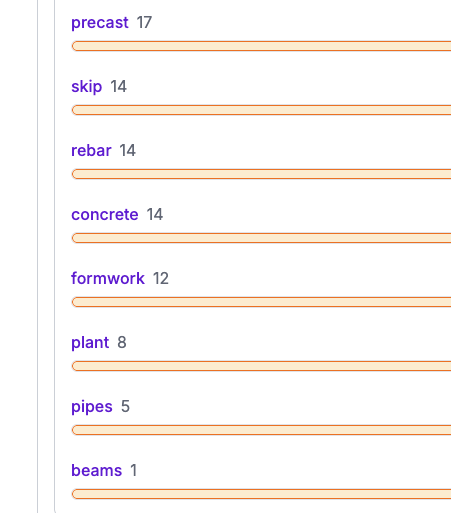

In [ ]:
test_cls_count = testset_df['gt_class'].value_counts().to_dict(); test_cls_count

In [ ]:
classes = list(test_cls_count.keys())
values = list(test_cls_count.values())

plt.figure(figsize=(4, 4))
plt.bar(classes, values, width=0.4)

plt.title("Test Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Precision / Recall

In [ ]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

In [ ]:
def precision(tp, fp):
  if (tp + fp) <=0:
    return 0

  return tp / (tp+fp)

def recall(tp, fn):
    if (tp + fn) <= 0:
        return 0
    return tp / (tp + fn)

def f1_score(prec, rec):
    if prec + rec <= 0:
        return 0
    return 2 * prec * rec / (prec + rec)

In [ ]:
test_classes, test_cls_count

In [ ]:
for cls in test_classes:
  cls_preds = res[res['pred_class'] == cls]

  #Calculate TP, NP, TN values
  tp = cls_preds['true'].sum()
  fp = len(cls_preds) - tp
  fn = test_cls_count[cls] - tp

  #Calculate metrics
  prec = precision(tp, fp)
  rec = recall(tp, fn)
  f1 = f1_score(prec, rec)

  cls_results = {
      'cls':cls,
      'AP':0,
      'precision':round(prec, 4),
      'recall':round(rec, 4),
      'f1':round(f1, 4)
      }
  print(cls_results)

In [ ]:
concrete_preds = res[res['pred_class'] == 'concrete'].sort_values(by='conf', ascending=False)
y_true = (concrete_preds['gt_class'] == 'concrete').astype(int).tolist()
y_score = concrete_preds['conf'].tolist()

In [ ]:
concrete_preds

In [ ]:
PrecisionRecallDisplay.from_predictions(
   y_true, y_score)

## Average Precision

In [ ]:
def get_ap_scores(result, all_classes):
  result = result.copy()
  result['conf'] = result['conf'].fillna(0.0)
  result['tp'] = (result['pred_class'] == result['gt_class']).astype(int)

  aps = {}
  raw_scores = []

  for cls in all_classes:
      num_gt = (result['gt_class'] == cls).sum()

      # Filter predictions where the model predicted 'cls'
      cls_preds = result[result['pred_class'] == cls].sort_values('conf', ascending=False)

      if len(cls_preds) == 0 or num_gt == 0:
          aps[cls] = 0.0
          continue

      y_true = cls_preds['tp'].values
      y_score = cls_preds['conf'].values

      pred_score = {"cls":cls, "y_true":y_true, "y_score":y_score}
      raw_scores.append(pred_score)

      # AP over actual predictions
      raw_ap = average_precision_score(y_true, y_score)

      # Scale AP by actual recall coverage (Total TPs detected / Total Ground Truths)
      total_tp = y_true.sum()
      fn_adjust = total_tp / num_gt if num_gt > 0 else 0.0

      aps[cls] = round(float(raw_ap * fn_adjust), 4)

  return aps, raw_scores

In [ ]:
res[res["pred_class"] == 'concrete']
res = res[res['conf'] >= 0.5]

In [ ]:
aps, raw_scores = get_ap_scores(res, test_classes); aps

In [ ]:
# for scores in raw_scores:
#   print(scores)
#   PrecisionRecallDisplay.from_predictions(
#    scores["y_true"], scores["y_score"])

In [ ]:
yolo_res = yolo_res.dropna(subset=['pred_class'])
yolo_res = yolo_res[['image', 'gt_box_index', 'pred_class_idx', 'pred_class', 'conf', 'iou']]


result = pd.merge(testset_df, yolo_res, on=['image', 'gt_box_index'], how='left');

In [ ]:
preds_50 = result[result['conf'] >= 0.50]

iou_match = preds_50['iou'] >= 0  #Look at other IOU thresholds?

class_match = preds_50['gt_class'] == cls
pred_match = preds_50['pred_class'] == cls

tp_50 = (iou_match & class_match & pred_match).sum()

In [ ]:
preds_50 = result[(result['conf'] >= 0.50) & (result['pred_class'] == 'concrete') & (result['gt_class'] == 'concrete')];preds_50

In [ ]:
import statistics

def Get_Metrics(res, classes, iou_threshold=0, conf_thresfold=0.5):
  cls_results = []
  aps, raw_scores = get_ap_scores(res, classes)

  # Total ground truth count per class across the dataset
  gt_counts = res['gt_class'].value_counts().to_dict()

  for cls in classes:
    cls_preds = res[res['pred_class'] == cls].sort_values(by='conf', ascending=False)

    # Total actual GT objects for this class
    num_cls = gt_counts.get(cls, 0)

    # Filter predictions at confidence >= 0.50
    preds_50 = cls_preds[cls_preds['conf'] >= conf_thresfold]

    # True Positives
    #Add IOU but currently set to 0 due to BB prediction sizes
    iou_match = preds_50['iou'] >= iou_threshold  #Look at other IOU types applicable?

    class_match = preds_50['gt_class'] == cls
    pred_match = preds_50['pred_class'] == cls

    tp_50 = (iou_match & class_match & pred_match).sum()
    fp = len(preds_50) - tp_50
    fn = num_cls - tp_50

    # Calculate metrics
    prec = precision(tp_50, fp)
    rec = recall(tp_50, fn)
    f1 = f1_score(prec, rec)

    # Save results
    cls_rows = {
      'cls': cls,
      'AP': aps.get(cls, 0.0),
      'precision': round(prec, 4),
      'recall': round(rec, 4),
      'f1': round(f1, 4)
    }
    cls_results.append(cls_rows)

  # Get all class AP scores and average for mAP
  APs = [cls['AP'] for cls in cls_results]
  mAP = round(statistics.mean(APs), 4) if len(APs) > 0 else 0.0

  return cls_results, mAP, raw_scores

In [ ]:
cls_res, mAP, raw_scores = Get_Metrics(result, test_classes, 0.1)

In [ ]:
mAP

In [ ]:
raw_scores

# Run Evalutations

## YOLO Only Eval

In [ ]:
testset_df = testset_df.copy()

In [ ]:
yolo_res = yolo_res.dropna(subset=['pred_class'])
yolo_res['image'] = yolo_res['image'].str.strip()
yolo_res = yolo_res[['image', 'gt_box_index', 'pred_class_idx', 'pred_class', 'conf', 'iou']]
yolo_merge = pd.merge(testset_df, yolo_res, on=['image', 'gt_box_index'], how='left'); yolo_merge.head()

In [ ]:
# yolo_merge[yolo_merge['pred_class'] == 'beams']

In [ ]:
yolo_results, yolo_mAP, raw_scores = Get_Metrics(yolo_merge, test_classes)

In [ ]:
yolo_res_df = pd.DataFrame.from_dict(yolo_results); yolo_res_df

In [ ]:
# Check beams
yolo_merge[yolo_merge['pred_class'] == 'beams']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def display_confusion_matrix(result, conf=0.5, title="Confusion Matrix"):
  result.dropna(subset=['pred_class'], inplace=True)
  result = result[result['conf'] >= conf]

  cm = confusion_matrix(
      result['gt_class'],
      result['pred_class'],
      labels=test_classes
  )

  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=test_classes
  )

  fig, ax = plt.subplots(figsize=(8, 8))
  disp.plot(ax=ax, cmap='Blues', xticks_rotation=45,
      colorbar=False)
  plt.title(title)
  plt.tight_layout()
  plt.show()

In [ ]:
display_confusion_matrix(yolo_merge, 0.5, "Confusion Matrix - YOLO Only")

## KYLE Eval


In [ ]:
testset_df = testset_df.copy()

kyle_results = kyle_results.dropna(subset=['pred_class'])
kyle_results['image'] = kyle_results['image'].str.strip()
kyle_results = kyle_results[['image', 'gt_box_index', 'pred_class_idx', 'pred_class', 'conf', 'iou']]
kyle_merge = pd.merge(testset_df, kyle_results, on=['image', 'gt_box_index'], how='left'); kyle_merge.head()

In [ ]:
kyle_results, kyle_mAP, raw_scores = Get_Metrics(kyle_merge, test_classes); kyle_results

In [ ]:
kyle_res_df = pd.DataFrame.from_dict(kyle_results); kyle_res_df

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

kyle_merge.dropna(subset=['pred_class'], inplace=True)

display_confusion_matrix(kyle_merge, 0.5, "Confusion Matrix - KYLE")